<a href="https://colab.research.google.com/github/MohammadRezaNamvarNejad/ABSA-LLM/blob/main/Mistral_7B_Instruct_v0_3_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U google-genai sentence-transformers faiss-cpu
!pip install -U bitsandbytes accelerate
!pip install huggingface_hub
!pip install -U bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00


In [2]:
import torch
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import gc
import re
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
import faiss

In [3]:
# ==========================================
# 1. Config and XML filename
# ==========================================
xml_filename = "ABSA16_Restaurants_Train_SB1_v2.xml"  # <-- check filename
model_name = "mistralai/Mistral-7B-Instruct-v0.3"

# ==========================================
# 2. Data loading and eval helpers
# ==========================================
def parse_semeval_xml(file_path):
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()
        dataset = []
        for review in root.findall('Review'):
            sentences = review.find('sentences')
            if sentences is None: continue
            for sentence in sentences.findall('sentence'):
                text = sentence.find('text').text
                opinions = sentence.find('Opinions')
                if opinions is None: continue
                for opinion in opinions.findall('Opinion'):
                    category = opinion.get('category')
                    polarity = opinion.get('polarity')
                    if polarity == "conflict": continue
                    dataset.append({"text": text, "aspect": category, "true_label": polarity})
        return dataset
    except FileNotFoundError:
        print("XML file not found — upload it first.")
        return []

# parse model output (benchmark rule 4)
def clean_output(output_text):
    output_text = output_text.lower().strip()
    # first valid keyword in the response
    match = re.search(r'\b(positive|negative|neutral)\b', output_text)
    if match:
        return match.group(1)
    return "neutral"  # default when parsing fails

In [4]:
# ==========================================
# 3. RAG per benchmark spec (section 1)
# ==========================================
class RAGRetriever:
    def __init__(self, train_samples):
        self.train_samples = train_samples
        if not train_samples: return
        # required embedding model
        self.encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
        print("Building RAG Index with FAISS...")
        sentences = [item['text'] for item in self.train_samples]
        embeddings = self.encoder.encode(sentences)
        # FAISS vector store
        self.index = faiss.IndexFlatL2(embeddings.shape[1])
        self.index.add(np.array(embeddings).astype('float32'))

    def retrieve(self, query_text, k=3):  # k must be 3
        if not self.train_samples: return []
        query_emb = self.encoder.encode([query_text])
        distances, indices = self.index.search(np.array(query_emb).astype('float32'), k)
        return [self.train_samples[idx] for idx in indices[0]]

In [5]:
# ==========================================
# 4. Unified prompt templates (sections 2-3)
# ==========================================
def get_prompt(mode, text, aspect, retrieved_examples=None):
    # shared zero-shot base
    base_instruction = (
        "Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.\n"
        "Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.\n"
        f'Sentence: "{text}"\n'
        f'Target Aspect: "{aspect}"\n'
        "Output ONLY the final sentiment label in lowercase."
    )

    if mode == "zero_shot":
        return base_instruction

    elif mode == "one_shot":
        # fixed hard-coded one-shot example
        prompt = (
            "Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.\n"
            "Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.\n\n"
            "Example:\n"
            'Sentence: "The food was absolutely delicious, but the service was terrible."\n'
            'Target Aspect: "food"\n'
            "Sentiment: positive\n\n"
            "Now classify the following:\n"
            f'Sentence: "{text}"\n'
            f'Target Aspect: "{aspect}"\n'
            "Sentiment:"
        )
        return prompt

    elif mode == "rag":
        # 3 retrieved examples for RAG
        prompt = (
            "Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.\n"
            "Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.\n\n"
            "Here are some reference examples:\n"
        )
        for i, ex in enumerate(retrieved_examples[:3]):
            prompt += f'Sentence: "{ex["text"]}" | Target Aspect: "{ex["aspect"]}" -> Sentiment: {ex["true_label"]}\n'

        prompt += (
            "\nNow classify the following:\n"
            f'Sentence: "{text}"\n'
            f'Target Aspect: "{aspect}"\n'
            "Sentiment:"
        )
        return prompt

In [8]:
from huggingface_hub import notebook_login
notebook_login()

In [9]:
# ==========================================
# 5. Model load and test loop
# ==========================================
print(f"🔄 Loading {model_name}...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)
tokenizer.pad_token = tokenizer.eos_token
print("✅ Model Loaded Successfully.")

# build example index
dataset = parse_semeval_xml(xml_filename)
if len(dataset) == 0:
    # dummy rows if XML missing (keeps notebook runnable)
    dataset = [{"text": "The pizza was great.", "aspect": "pizza", "true_label": "positive"}]

# init RAG
retriever = RAGRetriever(dataset)

# eval on first N samples for a quick pass
test_samples = dataset[:50]

results = {"Zero-Shot": 0, "One-Shot": 0, "RAG": 0}
modes = ["zero_shot", "one_shot", "rag"]

for mode in modes:
    correct = 0
    print(f"Running {mode.upper()} Evaluation...")

    for sample in test_samples:
        retrieved = retriever.retrieve(sample['text'], k=3) if mode == "rag" else None

        # build final prompt text
        raw_prompt = get_prompt(mode, sample['text'], sample['aspect'], retrieved)

        # wrap as a single user message
        messages = [{"role": "user", "content": raw_prompt}]

        # tensorize inputs and move to GPU
        inputs = tokenizer.apply_chat_template(messages, return_tensors="pt")

        # unwrap BatchEncoding -> input_ids
        if isinstance(inputs, dict) or hasattr(inputs, "data"):
            input_ids = inputs["input_ids"].to(model.device)
        else:
            input_ids = inputs.to(model.device)

        input_length = input_ids.shape[1]

        # deterministic generation
        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,     # explicit input_ids
                max_new_tokens=10,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        # decode only tokens after the prompt
        decoded = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)
        predicted_label = clean_output(decoded)

        if predicted_label == sample['true_label'].lower():
            correct += 1

    acc = (correct / len(test_samples)) * 100
    if mode == "zero_shot": results["Zero-Shot"] = acc
    elif mode == "one_shot": results["One-Shot"] = acc
    elif mode == "rag": results["RAG"] = acc
    print(f"  -> Accuracy: {acc:.2f}%")

🔄 Loading mistralai/Mistral-7B-Instruct-v0.3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✅ Model Loaded Successfully.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Building RAG Index with FAISS...
Running ZERO_SHOT Evaluation...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  -> Accuracy: 92.00%
Running ONE_SHOT Evaluation...
  -> Accuracy: 96.00%
Running RAG Evaluation...
  -> Accuracy: 94.00%



نتایج یکپارچه مدل:
      Method  Accuracy
0  Zero-Shot      92.0
1   One-Shot      96.0
2        RAG      94.0


/tmp/ipykernel_1527/1574888544.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Method", y="Accuracy", data=df_results, palette="viridis")


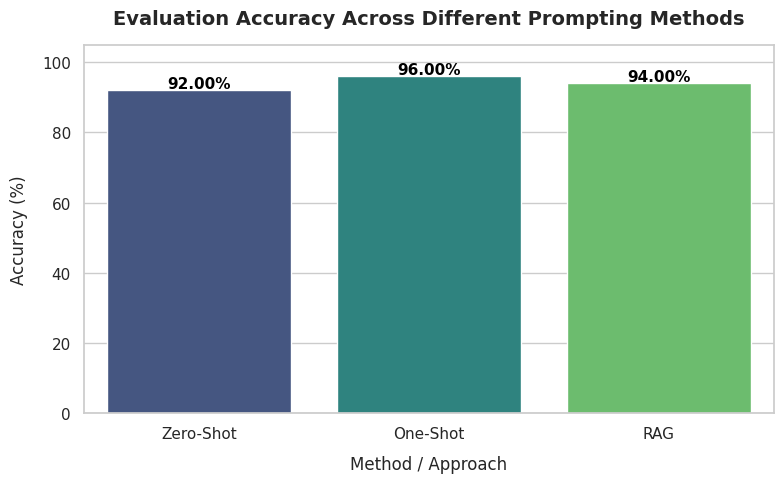

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# results -> DataFrame
df_results = pd.DataFrame(list(results.items()), columns=["Method", "Accuracy"])
print("\nModel results:")
print(df_results)

# ==========================================
# 6. Plot results
# ==========================================
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# grouped bar chart
ax = sns.barplot(x="Method", y="Accuracy", data=df_results, palette="viridis")

# chart cosmetics
plt.title("Evaluation Accuracy Across Different Prompting Methods", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Method / Approach", fontsize=12, labelpad=10)
plt.ylabel("Accuracy (%)", fontsize=12, labelpad=10)
plt.ylim(0, 105)  # y-axis headroom for labels

# percent labels on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 2),
                ha='center', va='center',
                fontsize=11, fontweight='bold', color='black',
                xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()